In [1]:
%cd ..

/home/eli/AnacondaProjects/wgvp_pc


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys

In [3]:
from src import test, train

In [4]:
def r2(xs, xs_hat):
    squared_errors = ((xs - xs_hat) ** 2).sum()
    total_squares = ((xs - xs.mean(axis=0, keepdims=True)) ** 2).sum()
    return 1.0 - squared_errors / (total_squares + jnp.finfo("float64").eps)

def portion_zeros(zs):
    return (zs == 0).mean()

In [5]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-01-25_21-31-55/saved/checkpoint-epoch2000.npy",
                                                            "+experiment=pvae_vh16_ovis_seed0", "hydra.runtime.output_dir=logs/test"], return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [6]:
metrics

{'loss': np.float32(42263.184),
 'loss_batch_mean': np.float32(330.18112),
 'log_w': np.float32(-42885.387),
 'log_w_batch_mean': np.float32(-335.04208)}

In [7]:
for data, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 16, 16)
    break

/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:78: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)


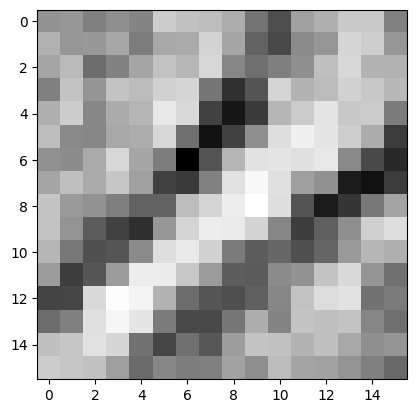

In [8]:
plt.imshow(recons[0].squeeze(), cmap="Greys")

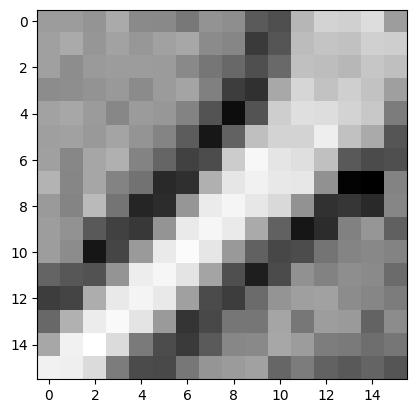

In [9]:
plt.imshow(data[0].squeeze(), cmap="Greys")

In [10]:
xs, xs_hat, zs = [], [], []

for data, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 16, 16)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:78: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)


In [11]:
portion_zeros(zs)

Array(0.43146423, dtype=float32)

In [12]:
r2(xs, xs_hat)

Array(0.3258118, dtype=float32)

In [13]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-01-25_20-32-57/saved/checkpoint-epoch2000.npy",
                                                            "+experiment=pvae_vh16_ovis_seed1", "hydra.runtime.output_dir=logs/test"], return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [14]:
metrics

{'loss': np.float32(42339.184),
 'loss_batch_mean': np.float32(330.77487),
 'log_w': np.float32(-42975.043),
 'log_w_batch_mean': np.float32(-335.74252)}

In [15]:
for data, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 16, 16)
    break

/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:78: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)


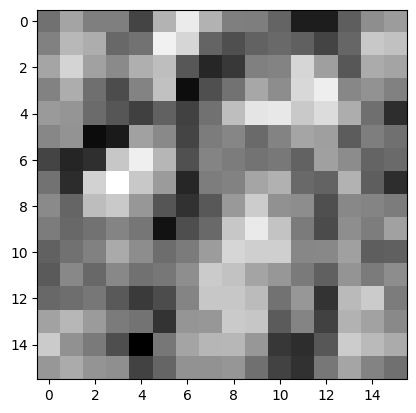

In [16]:
plt.imshow(recons[0].squeeze(), cmap="Greys")

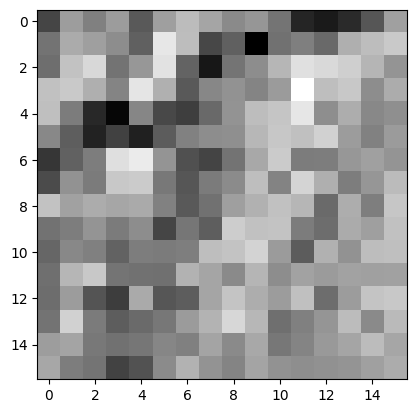

In [17]:
plt.imshow(data[0].squeeze(), cmap="Greys")

In [18]:
xs, xs_hat, zs = [], [], []

for data, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 16, 16)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [19]:
portion_zeros(zs)

Array(0.42823315, dtype=float32)

In [20]:
r2(xs, xs_hat)

Array(0.31888098, dtype=float32)

In [21]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-01-25_23-42-13/saved/checkpoint-epoch2000.npy",
                                                            "+experiment=pvae_vh16_ovis_seed2", "hydra.runtime.output_dir=logs/test"], return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [22]:
metrics

{'loss': np.float32(43374.35),
 'loss_batch_mean': np.float32(338.86212),
 'log_w': np.float32(-43998.496),
 'log_w_batch_mean': np.float32(-343.73825)}

In [23]:
for data, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 16, 16)
    break

/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:78: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)


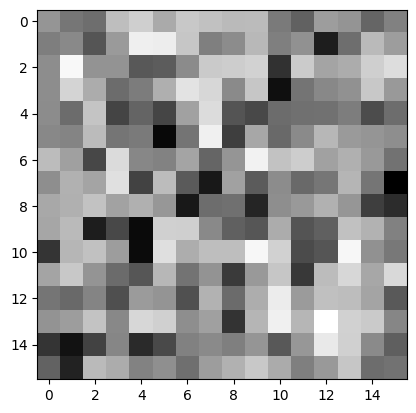

In [24]:
plt.imshow(recons[0].squeeze(), cmap="Greys")

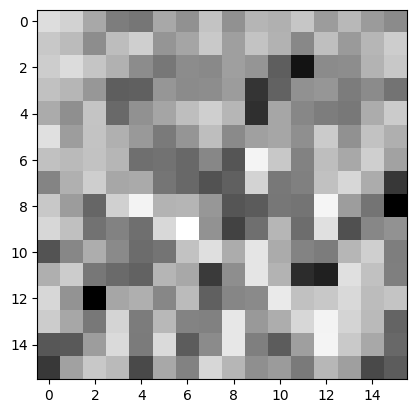

In [25]:
plt.imshow(data[0].squeeze(), cmap="Greys")

In [26]:
xs, xs_hat, zs = [], [], []

for data, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 16, 16)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [27]:
portion_zeros(zs)

Array(0.4624445, dtype=float32)

In [28]:
r2(xs, xs_hat)

Array(0.20998228, dtype=float32)